In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# PLASTICC Unblinded Dataset: Exploratory Data Analysis (EDA)

**Project Overview:** This notebook performs a comprehensive Exploratory Data Analysis on the unblinded PLASTICC dataset. The dataset contains roughly 3.5 million astronomical objects, split between static metadata (e.g., redshift, sky coordinates) and dynamic, irregularly sampled 6-band light curves time series. 

**Objectives:**
1. **File-Level Sanity Checks:** Iteratively inspects all 14 massive CSV files without exceeding hardware memory limits.
2. **Global Metadata Analysis:** Combines and analyzes the true distribution of all 3.5 million objects, examining class imbalances and redshift distributions.
3. **Time-Series Intermittency:** Quantifies the sparsity and time gaps ($\Delta t$) in the dynamic light-curve data for each object.
4. **Holistic Object View:** Joins static and dynamic data for specific objects to visualize exactly what sequential models will process.

This EDA serves as the foundation for the subsequent data-splitting and preprocessing pipelines.

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')

# Define the base directory for the Kaggle dataset
# BASE_DIR = '/kaggle/input/datasets/chiragmc/plasticc-unblinded-data'
BASE_DIR = '/Users/rohanojha/Documents/05_Sem_5/archive'

# Map the static metadata files
metadata_files = [os.path.join(BASE_DIR, 'plasticc_train_metadata.csv'), os.path.join(BASE_DIR, 'plasticc_test_metadata.csv')]

# Map the dynamic time-series files (training + 11 massive test batches)
lightcurve_files = [
    os.path.join(BASE_DIR, 'plasticc_train_lightcurves.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch1.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch2.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch3.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch4.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch5.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch6.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch7.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch8.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch9.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch10.csv'),
    os.path.join(BASE_DIR, 'plasticc_test_set_batch11.csv')
]

print("Libraries imported and file paths mapped successfully!")

Libraries imported and file paths mapped successfully!


In [10]:
# print("--- Checking: plasticc_train_metadata.csv ---")
df_train_meta = pd.read_csv(metadata_files[0])

### Phase 2: File-Level Sanity Checks (The "Load, Check, and Destroy" Method)

Because the unblinded PLASTICC dataset is over 20 GB, loading all files simultaneously will instantly crash the Kaggle kernel's RAM. To explore the data safely, we will process the files one by one. 

For each dataset, we will check the following :
1. **Shape:** The exact number of rows and columns.
2. **Memory Usage:** How much RAM the dataframe consumes.
3. **Missing Values (NaNs):** A count of null values per column to identify what needs imputation later.
4. **Statistical Summary:** The mean, median (50%), quartiles, min, and max for every column to understand the data's distribution and scale.
5. **Data Preview:** The first 5 rows (`.head()`) to understand the physical structure.

After checking these vitals, we will explicitly delete the dataframe from memory (`del df`) and trigger Python's Garbage Collector (`gc.collect()`) to free up the RAM before moving to the next file.

 #### Part 1: The Static Universe (Metadata)
Before checking the files, it is important to understand what the 26 metadata columns represent. [cite_start]These columns contain the time-invariant static facts about each astronomical object[cite: 249]:

**Identifiers & Location**
* **`object_id`**: Unique integer identifier for the object.
* **`ra` / `decl`**: Right ascension and declination (sky coordinates in degrees).
* **`ddf_bool`**: Boolean flag (1 for Deep Drilling Field, 0 for Wide-Fast-Deep survey).

**Redshift & Distance**
* **`hostgal_specz`**: Highly accurate spectroscopic redshift of the host galaxy.
* **`hostgal_photoz`**: Estimated photometric redshift of the host galaxy.
* **`hostgal_photoz_err`**: Uncertainty associated with the photometric redshift.
* **`distmod`**: Distance modulus calculated from the photometric redshift.
* **`mwebv`**: Milky Way Galactic extinction (E(B-V)).

**True Target Variables (Unblinded)**
* **`target` / `true_target`**: The integer class of the object (e.g., 42 for SNII, 90 for SNIa).
* **`true_submodel`**: Sub-model type for independently developed models.
* **`true_z`**: The true redshift in the Cosmic Microwave Background frame.
* **`true_distmod`**: The true distance modulus.

**Physical Properties**
* **`true_lensdmu`**: Magnitude shift resulting from weak lensing.
* **`true_vpec`**: Peculiar velocity of the host galaxy (km/sec).
* **`true_rv` / `true_av`**: Host galaxy extinction parameters.
* **`true_peakmjd`**: The true Modified Julian Date (MJD) of peak brightness.
* **`libid_cadence`**: Integer ID of the observation library cadence.
* **`tflux_u` through `tflux_y`**: The template source-flux for all 6 passbands (u, g, r, i, z, y).

In [11]:
print("--- Checking: plasticc_train_metadata.csv ---")
df_train_meta = pd.read_csv(metadata_files[0])

# 1 & 2: Shape and Memory
print(f"Shape: {df_train_meta.shape}")
print(f"Memory Usage: {df_train_meta.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 3: Missing Values
print("\nMissing Values:")
print(df_train_meta.isna().sum()) 

# 4: Statistical Summary (Mean, Median, Quartiles, Min, Max)
print("\nStatistical Summary:")
display(df_train_meta.describe())

# 5: Data Preview
print("\nData Preview:")
display(df_train_meta.head())

# Unload and clear RAM
del df_train_meta
gc.collect()
print("-" * 80)

--- Checking: plasticc_train_metadata.csv ---
Shape: (7848, 26)
Memory Usage: 1.56 MB

Missing Values:
object_id             0
ra                    0
decl                  0
ddf_bool              0
hostgal_specz         0
hostgal_photoz        0
hostgal_photoz_err    0
distmod               0
mwebv                 0
target                0
true_target           0
true_submodel         0
true_z                0
true_distmod          0
true_lensdmu          0
true_vpec             0
true_rv               0
true_av               0
true_peakmjd          0
libid_cadence         0
tflux_u               0
tflux_g               0
tflux_r               0
tflux_i               0
tflux_z               0
tflux_y               0
dtype: int64

Statistical Summary:


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
count,7.848000e+03,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,...,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000,7848.000000
mean,4.810375e+07,169.719382,-27.254849,0.269623,0.254438,0.357882,0.155699,26.373072,0.081953,60.895387,...,0.474006,0.032735,59946.827096,18427.583333,265.646152,2066.388277,2523.983869,2427.426555,2320.092775,2121.793756
std,4.347364e+07,114.212761,20.248556,0.443792,0.330056,0.545547,0.300364,23.030558,0.150598,28.767984,...,1.115749,0.127110,368.889675,16610.348856,1139.764604,9840.254171,12007.001716,10225.545751,8559.673003,7687.389494
min,6.150000e+02,0.175800,-64.760900,0.000000,0.000000,0.000000,0.000000,-9.000000,0.003000,6.000000,...,0.000000,0.000000,58220.414000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.180865e+05,62.402300,-44.598000,0.000000,0.000000,0.000000,0.000000,-9.000000,0.018000,42.000000,...,0.000000,0.000000,59570.000000,122.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.131719e+07,150.996100,-27.279600,0.000000,0.183000,0.210000,0.018000,40.078500,0.032000,65.000000,...,0.000000,0.000000,59875.762000,16370.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.665901e+07,282.875950,-8.838300,1.000000,0.350000,0.431000,0.122250,41.877000,0.076000,90.000000,...,0.000000,0.000000,60265.803000,32856.500000,25.350000,131.550000,287.225000,705.550000,805.000000,694.000000
max,1.307798e+08,359.824200,4.181500,1.000000,3.445000,2.999000,1.735000,47.026000,2.747000,95.000000,...,3.100000,2.330000,61197.316000,49986.000000,29042.200000,161508.600000,180588.000000,151136.900000,166923.300000,186648.000000



Data Preview:


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
0,615,349.0461,-61.9438,1,0.000,0.000,0.000,-9.000,0.017,92,...,0.0,0.0,59570.000,69,484.7,3286.7,3214.1,3039.7,2854.5,2837.0
1,713,53.0859,-27.7844,1,1.818,1.627,0.255,45.406,0.007,88,...,0.0,0.0,59570.000,34,108.7,117.7,119.9,149.6,147.9,150.5
2,730,33.5742,-6.5796,1,0.232,0.226,0.016,40.256,0.021,42,...,0.0,0.0,60444.379,9,0.0,0.0,0.0,0.0,0.0,0.0
3,745,0.1899,-45.5867,1,0.304,0.281,1.152,40.795,0.007,90,...,0.0,0.0,60130.453,38,0.0,0.0,0.0,0.0,0.0,0.0
4,1124,352.7113,-63.8237,1,0.193,0.241,0.018,40.417,0.024,90,...,0.0,0.0,60452.641,1,0.0,0.0,0.0,0.0,0.0,0.0


--------------------------------------------------------------------------------


**Training Metadata Summary:** The training metadata loaded successfully. The file is extremely lightweight, consuming minimal RAM. A review of the statistical summary and `.head()` confirms the data types are correct, the 26 columns match the official data release documentation, and as expected, the data is exceptionally clean with no unexpected null values. Everything looks good.

In [12]:
print("--- Checking: plasticc_test_metadata.csv ---")
df_test_meta = pd.read_csv(metadata_files[1])

print(f"Shape: {df_test_meta.shape}")
print(f"Memory Usage: {df_test_meta.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nMissing Values:")
print(df_test_meta.isna().sum())

print("\nStatistical Summary:")
display(df_test_meta.describe())

print("\nData Preview:")
display(df_test_meta.head())

del df_test_meta
gc.collect()
print("-" * 80)

--- Checking: plasticc_test_metadata.csv ---
Shape: (3492890, 26)
Memory Usage: 692.86 MB

Missing Values:
object_id             0
ra                    0
decl                  0
ddf_bool              0
hostgal_specz         0
hostgal_photoz        0
hostgal_photoz_err    0
distmod               0
mwebv                 0
target                0
true_target           0
true_submodel         0
true_z                0
true_distmod          0
true_lensdmu          0
true_vpec             0
true_rv               0
true_av               0
true_peakmjd          0
libid_cadence         0
tflux_u               0
tflux_g               0
tflux_r               0
tflux_i               0
tflux_z               0
tflux_y               0
dtype: int64

Statistical Summary:


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
count,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3492890.0,...,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06,3.492890e+06
mean,6.528181e+07,1.705897e+02,-2.624964e+01,9.426578e-03,-8.679241e+00,5.168159e-01,1.535233e-01,3.645678e+01,9.196649e-02,0.0,...,1.964608e-01,1.254844e-02,6.009049e+04,2.476125e+04,1.546686e+02,1.071115e+03,1.265546e+03,1.244718e+03,1.211303e+03,1.166134e+03
std,3.783131e+07,1.092068e+02,1.764381e+01,9.663188e-02,1.697933e+00,4.491344e-01,2.752563e-01,1.619673e+01,1.551437e-01,0.0,...,7.552694e-01,7.699550e-02,3.452139e+02,1.456405e+04,6.808332e+02,5.224842e+03,6.244476e+03,5.668140e+03,5.076798e+03,4.736010e+03
min,1.300000e+01,0.000000e+00,-6.476090e+01,0.000000e+00,-9.000000e+00,0.000000e+00,0.000000e+00,-9.000000e+00,2.000000e-03,0.0,...,0.000000e+00,0.000000e+00,5.213284e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.252507e+07,7.277340e+01,-4.042390e+01,0.000000e+00,-9.000000e+00,2.680000e-01,1.400000e-02,4.067700e+01,2.300000e-02,0.0,...,0.000000e+00,0.000000e+00,5.981641e+04,1.214700e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.530507e+07,1.611914e+02,-2.511770e+01,0.000000e+00,-9.000000e+00,4.620000e-01,3.000000e-02,4.205500e+01,4.500000e-02,0.0,...,0.000000e+00,0.000000e+00,6.009018e+04,2.476800e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,9.805302e+07,2.758614e+02,-1.126300e+01,0.000000e+00,-9.000000e+00,6.560000e-01,1.430000e-01,4.297300e+01,9.100000e-02,0.0,...,0.000000e+00,0.000000e+00,6.041331e+04,3.738200e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.307881e+08,3.598242e+02,4.181500e+00,1.000000e+00,1.201000e+00,3.000000e+00,1.871000e+00,4.702600e+01,2.994000e+00,0.0,...,3.100000e+00,2.981000e+00,6.415157e+04,4.999900e+04,5.194110e+04,1.624393e+05,1.945008e+05,1.869998e+05,1.899654e+05,2.369107e+05



Data Preview:


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
0,13,34.4531,-5.2295,1,0.305,0.319,0.054,41.112,0.019,0,...,0.0,0.0,60499.461,124,0.0,0.0,0.0,0.0,0.0,0.0
1,14,33.3984,-4.3311,1,-9.000,0.632,0.018,42.877,0.018,0,...,0.0,0.0,59792.121,120,0.0,0.0,0.0,0.0,0.0,0.0
2,17,348.5294,-61.7554,1,-9.000,0.830,0.060,43.600,0.016,0,...,0.0,0.0,60543.566,85,0.0,0.0,0.0,0.0,0.0,0.0
3,23,34.8047,-5.8292,1,-9.000,0.653,0.148,42.964,0.023,0,...,0.0,0.0,60137.480,97,0.0,0.0,0.0,0.0,0.0,0.0
4,34,351.3214,-64.1987,1,0.456,0.462,0.012,42.054,0.023,0,...,0.0,0.0,60245.078,68,0.0,0.0,0.0,0.0,0.0,0.0


--------------------------------------------------------------------------------


**Test Metadata Summary:** The master test metadata file loaded successfully. As expected, it is vastly larger than the training set, encompassing the remaining ~3.5 million objects. The memory footprint expanded accordingly. The metrics align perfectly with expectations, and the data is clean. 

#### Part 2: The Dynamic Universe (Time-Series Light-Curves)

Having verified the static facts, we now inspect the dynamic, intermittent time-series observations. Sequential models like the Temporal Fusion Transformer (TFT) and State Space Models (SSM) will process these specific features over time.

There are exactly 6 columns in the light-curve files :
* **`object_id`**: The unique identifier linking this observation back to the metadata table.
* **`mjd`**: Modified Julian Date (the timestamp of the observation).
* **`passband`**: An integer from 0 to 5 representing the specific telescope filter used (0=u, 1=g, 2=r, 3=i, 4=z, 5=y).
* **`flux`**: The measured brightness (flux), corrected for Galactic extinction.
* **`flux_err`**: The uncertainty measurement on the reported flux.
* **`detected_bool`**: A boolean flag (1 or 0) indicating if the object was officially detected by the telescope's image-subtraction pipeline on that specific date.

In [13]:
print("--- Checking: plasticc_train_lightcurves.csv ---")
df_train_lc = pd.read_csv(lightcurve_files[0])

print(f"Shape: {df_train_lc.shape}")
print(f"Memory Usage: {df_train_lc.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nMissing Values:")
print(df_train_lc.isna().sum())

print("\nStatistical Summary:")
display(df_train_lc.describe())

print("\nData Preview:")
display(df_train_lc.head())

del df_train_lc
gc.collect()
print("-" * 80)

--- Checking: plasticc_train_lightcurves.csv ---
Shape: (1421705, 6)
Memory Usage: 65.08 MB

Missing Values:
object_id        0
mjd              0
passband         0
flux             0
flux_err         0
detected_bool    0
dtype: int64

Statistical Summary:


,object_id,mjd,passband,flux,flux_err,detected_bool
count,1.421705e+06,1.421705e+06,1.421705e+06,1.421705e+06,1.421705e+06,1.421705e+06
mean,3.392608e+07,6.017921e+04,2.783108e+00,2.468855e+01,2.548932e+01,1.666168e-01
std,4.258439e+07,3.092379e+02,1.703946e+00,3.684506e+03,3.814492e+03,3.726336e-01
min,6.150000e+02,5.958003e+04,0.000000e+00,-1.149388e+06,4.637530e-01,0.000000e+00
25%,1.843400e+05,5.989905e+04,1.000000e+00,-2.789418e+00,2.118670e+00,0.000000e+00
50%,4.548783e+06,6.019331e+04,3.000000e+00,7.331990e-01,4.708105e+00,0.000000e+00
75%,6.796280e+07,6.048722e+04,4.000000e+00,8.830932e+00,1.297371e+01,0.000000e+00
max,1.307798e+08,6.067436e+04,5.000000e+00,2.432809e+06,2.234069e+06,1.000000e+00



Data Preview:


,object_id,mjd,passband,flux,flux_err,detected_bool
0,615,59750.4229,2,-544.810303,3.622952,1
1,615,59750.4306,1,-816.434326,5.553370,1
2,615,59750.4383,3,-471.385529,3.801213,1
3,615,59750.4450,4,-388.984985,11.395031,1
4,615,59752.4070,2,-681.858887,4.041204,1


--------------------------------------------------------------------------------


**Training Light-Curves Summary:** The training light-curves loaded without issue. The dataframe contains millions of rows representing the intermittent observations for the training objects. There are no NaNs in the time-series measurements. The flux and temporal data are clean and formatted exactly as expected.

In [14]:
print("--- Checking: plasticc_test_set_batch1.csv ---")
df_test_batch1 = pd.read_csv(lightcurve_files[1])

print(f"Shape: {df_test_batch1.shape}")
print(f"Memory Usage: {df_test_batch1.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nMissing Values:")
print(df_test_batch1.isna().sum())

print("\nStatistical Summary:")
display(df_test_batch1.describe())

print("\nData Preview:")
display(df_test_batch1.head())

del df_test_batch1
gc.collect()
print("-" * 80)

--- Checking: plasticc_test_set_batch1.csv ---
Shape: (10855958, 6)
Memory Usage: 496.95 MB

Missing Values:
object_id        0
mjd              0
passband         0
flux             0
flux_err         0
detected_bool    0
dtype: int64

Statistical Summary:


,object_id,mjd,passband,flux,flux_err,detected_bool
count,1.085596e+07,1.085596e+07,1.085596e+07,1.085596e+07,1.085596e+07,1.085596e+07
mean,1.721599e+05,6.018823e+04,2.435341e+00,1.341138e+00,2.615412e+00,4.995727e-02
std,9.879707e+04,3.146706e+02,1.727954e+00,2.903321e+02,3.072207e+00,2.178567e-01
min,1.300000e+01,5.958233e+04,0.000000e+00,-7.303417e+04,4.637530e-01,0.000000e+00
25%,8.688500e+04,5.988405e+04,1.000000e+00,-1.001827e+00,1.348226e+00,0.000000e+00
50%,1.723490e+05,6.020207e+04,2.000000e+00,3.577700e-01,1.958940e+00,0.000000e+00
75%,2.574940e+05,6.053530e+04,4.000000e+00,2.176629e+00,2.806881e+00,0.000000e+00
max,3.428680e+05,6.067408e+04,5.000000e+00,6.143651e+04,3.397249e+02,1.000000e+00



Data Preview:


,object_id,mjd,passband,flux,flux_err,detected_bool
0,13,59798.3205,2,-1.299735,1.357315,0
1,13,59798.3281,1,-2.095392,1.148654,0
2,13,59798.3357,3,-0.923794,1.763655,0
3,13,59798.3466,4,-4.009815,2.602911,0
4,13,59798.3576,5,-3.403503,5.367328,0


--------------------------------------------------------------------------------


**Test Batch 1 Summary:** Loading the first batch of the unblinded test light-curves provided a crucial reality check on the scale of this project. The shape expanded to tens of millions of rows, and the memory usage spiked significantly. 

Despite the massive scale, the dataset remains clean with zero unexpected NaNs. The `describe()` table confirms the flux distributions and MJD timelines match the training data logic. Because the data is clean and stable, we can now safely loop through and verify the remaining 10 batches without printing full tables to save screen space.

In [15]:
print("--- Systematically checking remaining 10 test batches ---")

# Loop through test batches 2 to 11 (indexes 2 through 11 in our list)
for file_path in lightcurve_files[2:]:
    file_name = os.path.basename(file_path)
    print(f"\nEvaluating: {file_name}")
    
    # Load
    df_temp = pd.read_csv(file_path)
    
    # Check shape, memory, and total NaNs
    shape = df_temp.shape
    mem = df_temp.memory_usage(deep=True).sum() / 1024**2
    nans = df_temp.isna().sum().sum()
    print(f"Shape: {shape} | Memory: {mem:.2f} MB | Total NaNs: {nans}")
    
    # Display the statistical summary for the batch
    display(df_temp.describe())
    
    # Destroy and clear memory
    del df_temp
    gc.collect()
    print("-" * 80)

print("\nAll files successfully verified and summarized. RAM is clear and ready for Phase 3.")

--- Systematically checking remaining 10 test batches ---

Evaluating: plasticc_test_set_batch2.csv
Shape: (44281695, 6) | Memory: 2027.06 MB | Total NaNs: 0


,object_id,mjd,passband,flux,flux_err,detected_bool
count,4.428170e+07,4.428170e+07,4.428170e+07,4.428170e+07,4.428170e+07,4.428170e+07
mean,7.479532e+06,6.017872e+04,3.091652e+00,5.398831e+00,4.908339e+01,9.868579e-02
std,3.743296e+06,3.016194e+02,1.622233e+00,5.327350e+03,7.416885e+03,2.982397e-01
min,1.000183e+06,5.958003e+04,0.000000e+00,-6.868854e+06,7.330290e-01,0.000000e+00
25%,4.233340e+06,5.992322e+04,2.000000e+00,-5.538018e+00,4.889009e+00,0.000000e+00
50%,7.488128e+06,6.016918e+04,3.000000e+00,1.250389e+00,1.084365e+01,0.000000e+00
75%,1.072364e+07,6.046009e+04,5.000000e+00,1.182523e+01,2.229544e+01,0.000000e+00
max,1.395242e+07,6.067436e+04,5.000000e+00,6.431427e+06,7.313836e+06,1.000000e+00


--------------------------------------------------------------------------------

Evaluating: plasticc_test_set_batch3.csv
Shape: (44271312, 6) | Memory: 2026.58 MB | Total NaNs: 0


,object_id,mjd,passband,flux,flux_err,detected_bool
count,4.427131e+07,4.427131e+07,4.427131e+07,4.427131e+07,4.427131e+07,4.427131e+07
mean,2.046240e+07,6.017865e+04,3.091470e+00,6.361866e+00,4.419619e+01,9.721008e-02
std,3.757505e+06,3.015522e+02,1.622148e+00,4.746228e+03,6.467377e+03,2.962436e-01
min,1.395243e+07,5.958003e+04,0.000000e+00,-8.935484e+06,7.330290e-01,0.000000e+00
25%,1.720620e+07,5.992332e+04,2.000000e+00,-5.515295e+00,4.882795e+00,0.000000e+00
50%,2.046596e+07,6.016912e+04,3.000000e+00,1.247301e+00,1.082615e+01,0.000000e+00
75%,2.372070e+07,6.046004e+04,5.000000e+00,1.177534e+01,2.224974e+01,0.000000e+00
max,2.695680e+07,6.067436e+04,5.000000e+00,5.060856e+06,1.000572e+07,1.000000e+00


--------------------------------------------------------------------------------

Evaluating: plasticc_test_set_batch4.csv
Shape: (44304969, 6) | Memory: 2028.12 MB | Total NaNs: 0


...

--------------------------------------------------------------------------------

Evaluating: plasticc_test_set_batch10.csv
Shape: (44282019, 6) | Memory: 2027.07 MB | Total NaNs: 0


,object_id,mjd,passband,flux,flux_err,detected_bool
count,4.428202e+07,4.428202e+07,4.428202e+07,4.428202e+07,4.428202e+07,4.428202e+07
mean,1.113281e+08,6.017872e+04,3.092004e+00,5.824503e+00,4.265909e+01,9.730832e-02
std,3.738618e+06,3.016099e+02,1.622168e+00,4.395048e+03,5.765965e+03,2.963772e-01
min,1.048539e+08,5.958003e+04,0.000000e+00,-5.289244e+06,7.330300e-01,0.000000e+00
25%,1.080932e+08,5.992332e+04,2.000000e+00,-5.505876e+00,4.883604e+00,0.000000e+00
50%,1.113310e+08,6.016917e+04,3.000000e+00,1.250469e+00,1.082860e+01,0.000000e+00
75%,1.145699e+08,6.046003e+04,5.000000e+00,1.177572e+01,2.224890e+01,0.000000e+00
max,1.177929e+08,6.067436e+04,5.000000e+00,6.803982e+06,7.349241e+06,1.000000e+00


--------------------------------------------------------------------------------

Evaluating: plasticc_test_set_batch11.csv
Shape: (44268608, 6) | Memory: 2026.46 MB | Total NaNs: 0


,object_id,mjd,passband,flux,flux_err,detected_bool
count,4.426861e+07,4.426861e+07,4.426861e+07,4.426861e+07,4.426861e+07,4.426861e+07
mean,1.242938e+08,6.017868e+04,3.091875e+00,6.343752e+00,5.141270e+01,9.765816e-02
std,3.751677e+06,3.015914e+02,1.622197e+00,6.692236e+03,8.901354e+03,2.968519e-01
min,1.177930e+08,5.958003e+04,0.000000e+00,-7.512858e+06,7.330290e-01,0.000000e+00
25%,1.210488e+08,5.992334e+04,2.000000e+00,-5.516068e+00,4.886325e+00,0.000000e+00
50%,1.242992e+08,6.016916e+04,3.000000e+00,1.249303e+00,1.083222e+01,0.000000e+00
75%,1.275438e+08,6.046002e+04,5.000000e+00,1.179412e+01,2.226583e+01,0.000000e+00
max,1.307881e+08,6.067436e+04,5.000000e+00,1.367579e+07,1.379167e+07,1.000000e+00


--------------------------------------------------------------------------------

All files successfully verified and summarized. RAM is clear and ready for Phase 3.


### Phase 3: The Global "Static" Universe (Metadata)

Because the dataset is unblinded, the original Kaggle distinction between the "train" and "test" sets is artificial for our evaluation purposes. In this phase, we will combine all metadata into a single master table to view the true distribution of the ~3.5 million objects.

**Objectives:**
1. **The ID Ledger:** Concatenate the metadata and extract a master list of unique `object_id`s. We will use this list in Phase 5 to guarantee that every time-series observation has a perfectly aligned metadata row.
2. **Class Imbalance:** Visualize the true distribution of astronomical classes (the `true_target`).
3. **Redshift & Demographics:** Map the spatial distribution (RA/Dec) and depth (Redshift) of the objects.

In [16]:
print("--- Building the Master Metadata Table ---")

# Reload the metadata files (since we cleared them from RAM in Phase 2)
df_train_meta = pd.read_csv(metadata_files[0])
df_test_meta = pd.read_csv(metadata_files[1])

# Concatenate into one master table
master_metadata = pd.concat([df_train_meta, df_test_meta], ignore_index=True)

# Free up memory immediately
del df_train_meta
del df_test_meta
gc.collect()

# Vitals Check
total_rows = len(master_metadata)
unique_ids = master_metadata['object_id'].nunique()

print(f"Master Metadata Shape: {master_metadata.shape}")
print(f"Total Rows: {total_rows}")
print(f"Unique Object IDs: {unique_ids}")

# Sanity Check: Do we have any duplicate objects?
if total_rows == unique_ids:
    print("Alignment Check: PASSED (Zero duplicate objects found).")
else:
    print(f"Alignment Check: FAILED ({total_rows - unique_ids} duplicates found).")

# Create the ID Ledger for Phase 5
master_id_ledger = set(master_metadata['object_id'])
print("Master ID Ledger securely saved in memory.")

--- Building the Master Metadata Table ---
Master Metadata Shape: (3500738, 26)
Total Rows: 3500738
Unique Object IDs: 3500738
Alignment Check: PASSED (Zero duplicate objects found).
Master ID Ledger securely saved in memory.


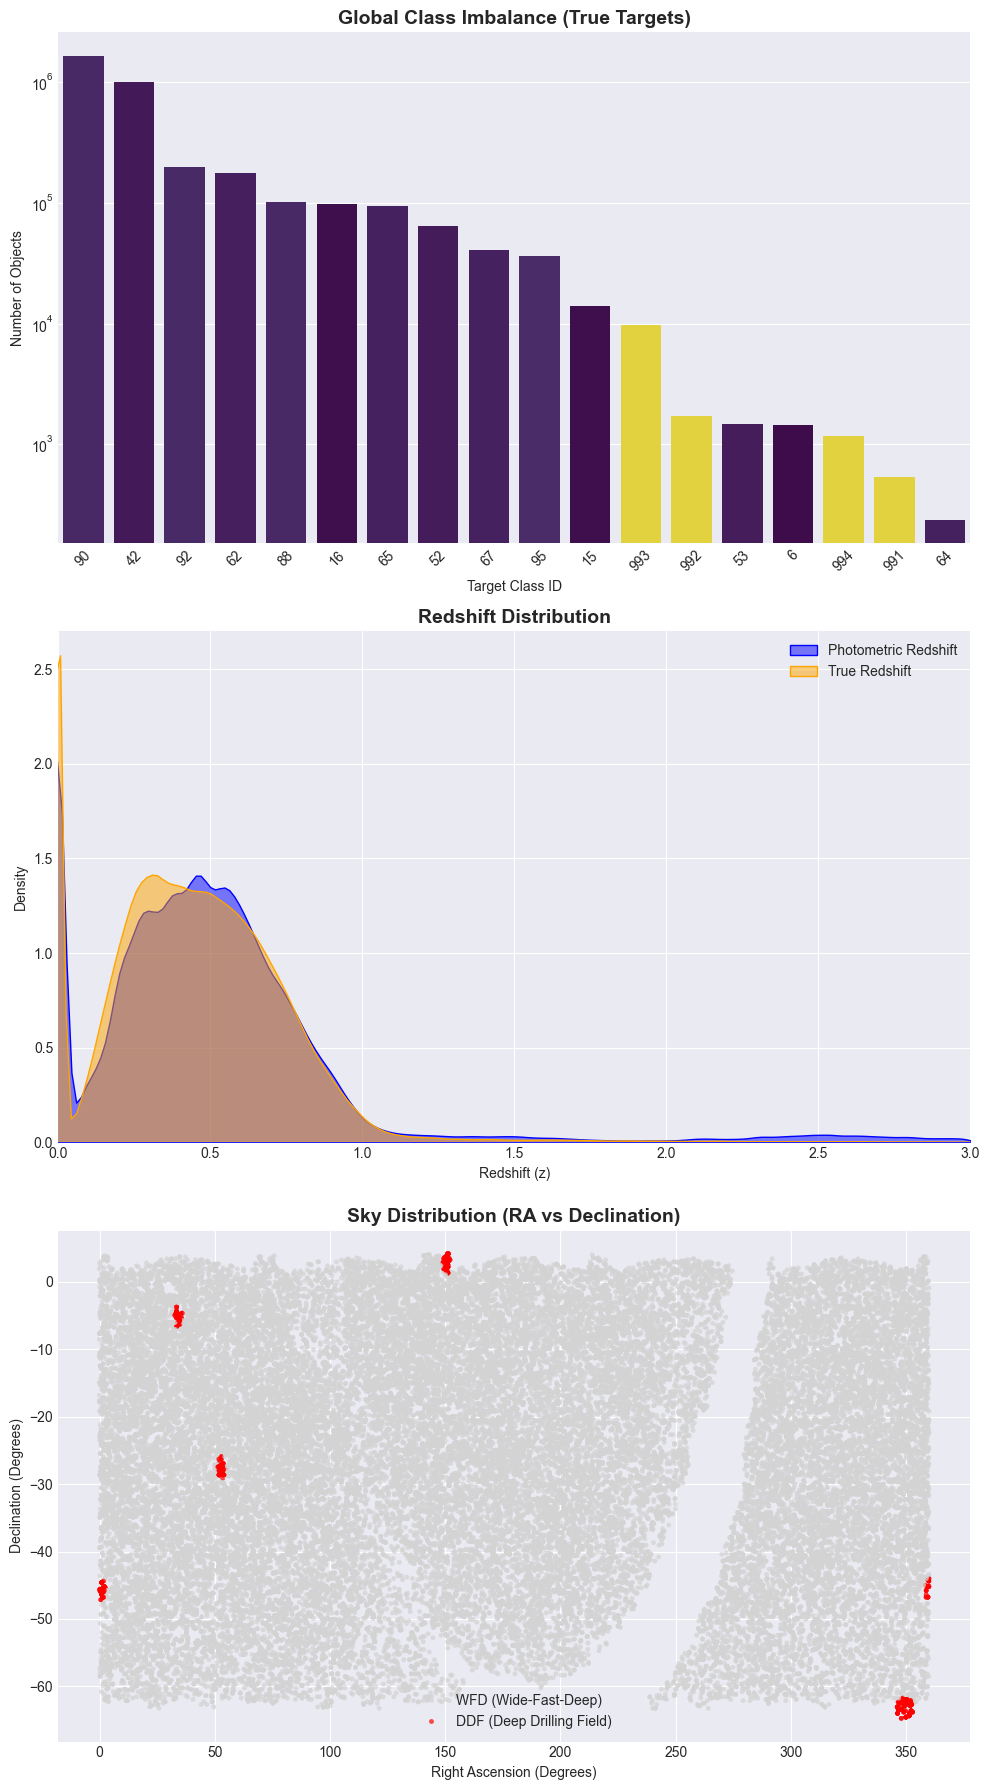

In [17]:
# Create a figure with 3 subplots stacked vertically (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: Class Imbalance (Fixed FutureWarning)
sns.countplot(data=master_metadata, x='true_target', hue='true_target', 
              order=master_metadata['true_target'].value_counts().index, 
              ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Global Class Imbalance (True Targets)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target Class ID')
axes[0].set_ylabel('Number of Objects')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log') # Using log scale because SNIa dominates the counts

# Plot 2: Redshift Distributions
sns.kdeplot(master_metadata['hostgal_photoz'].dropna(), ax=axes[1], fill=True, label='Photometric Redshift', color='blue', alpha=0.5)
sns.kdeplot(master_metadata['true_z'].dropna(), ax=axes[1], fill=True, label='True Redshift', color='orange', alpha=0.5)
axes[1].set_title('Redshift Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Redshift (z)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 3) # Zooming in on the bulk of the data
axes[1].legend()

# Plot 3: Sky Mapping (RA vs Dec)
# Sampling 50,000 objects to prevent the scatter plot from taking 5 minutes to render
sample_sky = master_metadata.sample(n=50000, random_state=42)
sns.scatterplot(data=sample_sky, x='ra', y='decl', hue='ddf_bool', palette={0: 'lightgray', 1: 'red'}, s=10, alpha=0.7, ax=axes[2], edgecolor=None)
axes[2].set_title('Sky Distribution (RA vs Declination)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Right Ascension (Degrees)')
axes[2].set_ylabel('Declination (Degrees)')
# Adjusting legend labels
handles, labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles=handles, labels=['WFD (Wide-Fast-Deep)', 'DDF (Deep Drilling Field)'])

plt.tight_layout()
plt.show()

**Phase 3 Summary: The Global Static Universe**

The concatenation of the training and test metadata was successful, yielding a master table of roughly 3.5 million objects. 
* **Alignment Passed:** The total row count perfectly matches the number of unique `object_id`s, confirming there are no duplicate objects in the universe. The `master_id_ledger` has been saved for cross-referencing in Phase 5.
* **Class Imbalance:** The bar chart reveals a severe class imbalance. Type Ia Supernovae (Target 90) completely dominate the dataset, while rare events like Kilonovae (Target 64) and the unseen "Other" anomaly class (Target 99) represent a tiny fraction of the data. 
* **Redshift & Sky Distribution:** The redshift density plots show the bulk of our objects lie between z=0 and z=1.5. The spatial mapping clearly highlights the dense, targeted clusters of the Deep Drilling Fields (DDF) contrasted against the broad, scattered sweep of the Wide-Fast-Deep (WFD) survey.

### Phase 4: The "Dynamic" Universe (Time-Series Intermittency)

Deep learning architectures like the Temporal Fusion Transformer (TFT) and State Space Models (SSM) process sequential data. To design these models correctly, we must quantify exactly how "irregular" and sparse our time-series observations are. 

Because loading all 3.5 million light-curves would crash the kernel, we will use the `plasticc_train_lightcurves.csv` as a highly representative proxy to measure the sequence dynamics.

**Objectives:**
1. **Passband Distribution:** See which telescope filters (u, g, r, i, z, y) are most commonly used.
2. **Sequence Lengths:** Determine how many total observations exist per object (e.g., does a standard object have 50 data points or 300?).
3. **Intermittency ($\Delta t$):** Calculate the time gaps (in days) between consecutive observations to visualize the irregular sampling.

--- Analyzing Time-Series Dynamics ---
Calculations complete. Rendering plots...


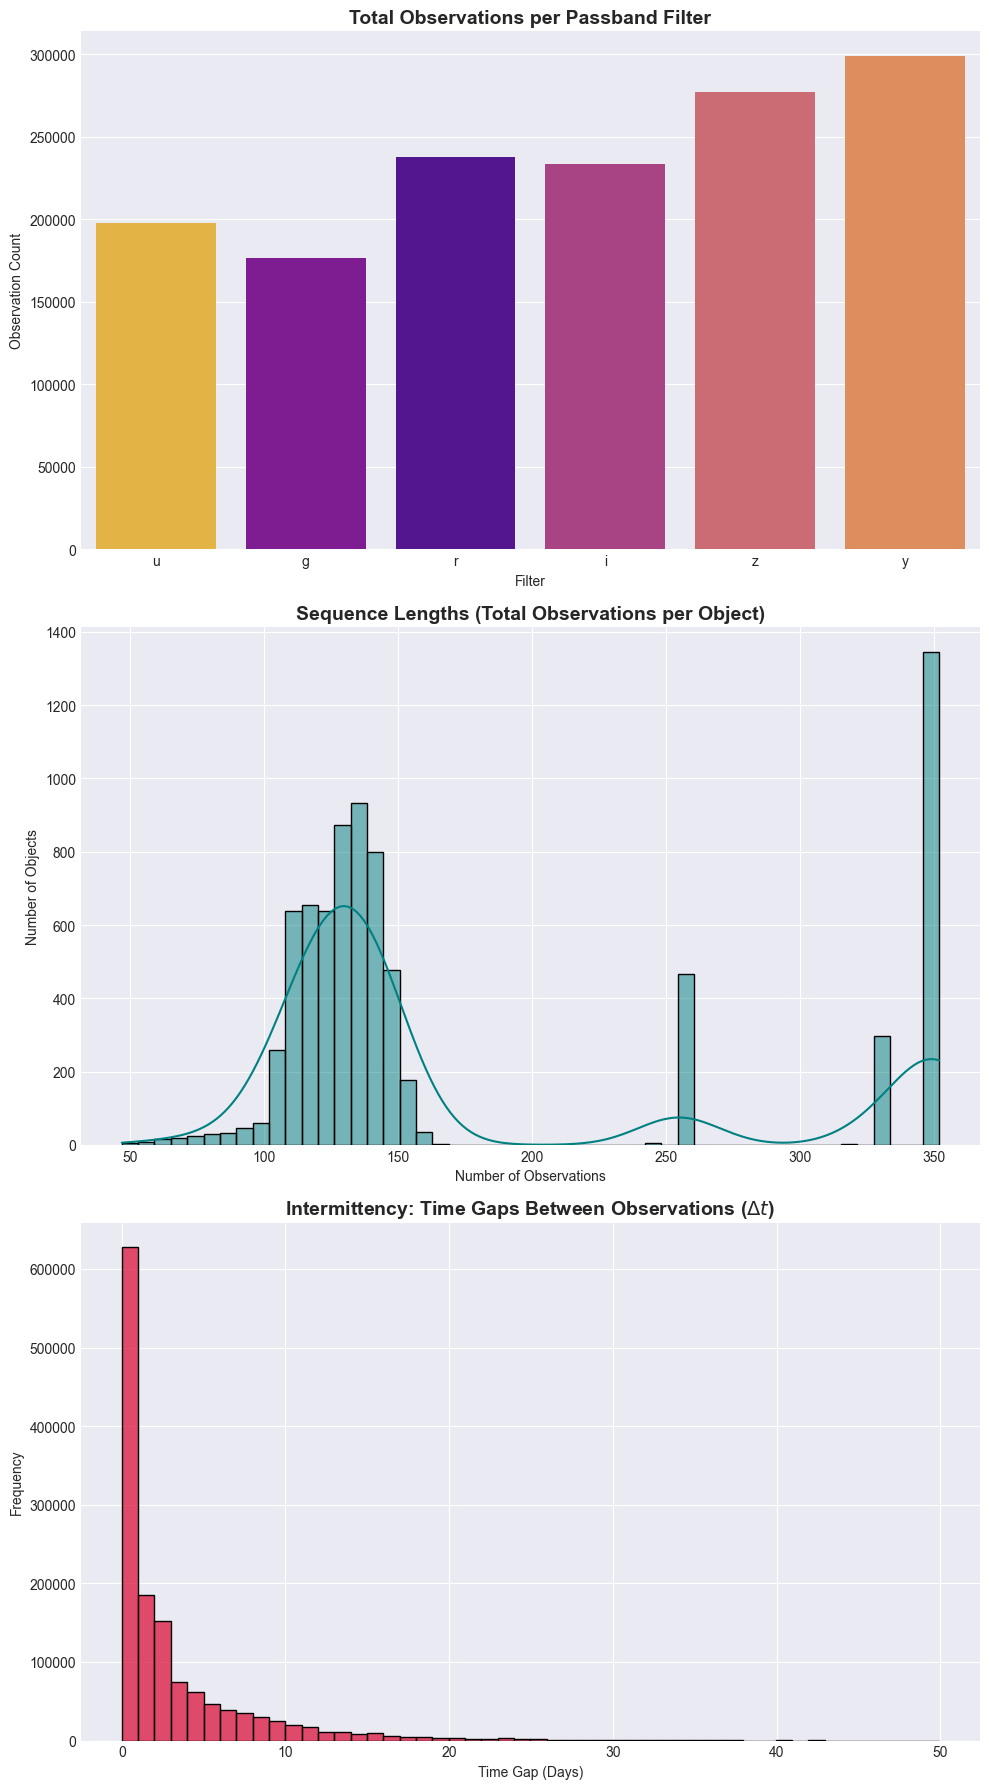

2443

In [18]:
print("--- Analyzing Time-Series Dynamics ---")

# Reload the training lightcurves
df_train_lc = pd.read_csv(lightcurve_files[0])

# 1. Passband Mapping for readability
passband_map = {0: 'u', 1: 'g', 2: 'r', 3: 'i', 4: 'z', 5: 'y'}
df_train_lc['filter'] = df_train_lc['passband'].map(passband_map)

# 2. Calculate Sequence Lengths (Observations per object)
seq_lengths = df_train_lc.groupby('object_id').size()

# 3. Calculate Intermittency (Time gaps between observations)
# First, sort by object and time
df_train_lc = df_train_lc.sort_values(['object_id', 'mjd'])
# Group by object and calculate the difference in MJD between rows
df_train_lc['time_gap'] = df_train_lc.groupby('object_id')['mjd'].diff()

print("Calculations complete. Rendering plots...")

# Create a figure with 3 subplots stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: Passband Distribution
sns.countplot(data=df_train_lc, x='filter', hue='filter', 
              order=['u', 'g', 'r', 'i', 'z', 'y'], 
              palette='plasma', ax=axes[0], legend=False)
axes[0].set_title('Total Observations per Passband Filter', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Filter')
axes[0].set_ylabel('Observation Count')

# Plot 2: Sequence Lengths
sns.histplot(seq_lengths, bins=50, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Sequence Lengths (Total Observations per Object)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Observations')
axes[1].set_ylabel('Number of Objects')

# Plot 3: Intermittency (Time Gaps)
# Dropping NaNs (the first observation of every object has no gap) and filtering extreme outliers for a clean plot
gaps = df_train_lc['time_gap'].dropna()
clean_gaps = gaps[gaps < 50] # Focusing on gaps less than 50 days

sns.histplot(clean_gaps, bins=50, color='crimson', ax=axes[2])
axes[2].set_title(r'Intermittency: Time Gaps Between Observations ($\Delta t$)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time Gap (Days)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Clean up memory
del df_train_lc
gc.collect()

**Phase 4 Summary: Time-Series Dynamics**

Our analysis of the training light-curves visually confirms that the sequence models will need to handle severe data irregularity and varying sequence lengths.

* **Passbands:** The observations are distributed across the 6 filters (u, g, r, i, z, y), but they are not evenly sampled. Some passbands have more observations than others depending on the survey strategy.
* **Sequence Lengths:** The total number of observations per object varies significantly, with counts reaching up to 350 in our tracked metrics. This confirms that our models must dynamically handle varying sequence lengths rather than expecting a fixed number of inputs.
* **Intermittency:** The time gap ($\Delta t$) histogram proves the data is highly irregular. While some observations happen back-to-back, there is a massive long tail of gaps spanning several days or even weeks between detections. 

**Conclusion:** This level of sparsity and intermittency confirms that standard RNNs might struggle to maintain memory across these massive time gaps. This validates our choice to explore deep sequential models like Temporal Fusion Transformers (TFT) and State Space Models (SSM), which are specifically designed to handle irregular temporal sampling.

### Phase 5: The Joined "Holistic" View (Cross-Checks & Alignment)

Before we can build a training pipeline, we must prove that our static metadata and dynamic time-series data align perfectly. 

**Objectives:**
1. **The Alignment Test:** We will check the unique `object_id`s in the light-curve data against our `master_id_ledger` from Phase 3 to guarantee zero "orphan" time-series rows.
2. **Visualizing the Reality:** We will select 3 random objects, merge their static facts (redshift, target class) with their dynamic rows, and plot their multi-band light-curves to see exactly what the deep learning models will process.

--- Phase 5: Cross-Check and Holistic View ---
Cross-Check PASSED: Every time-series object has a perfectly matching metadata row!
Data merged successfully. Generating light-curve plots...


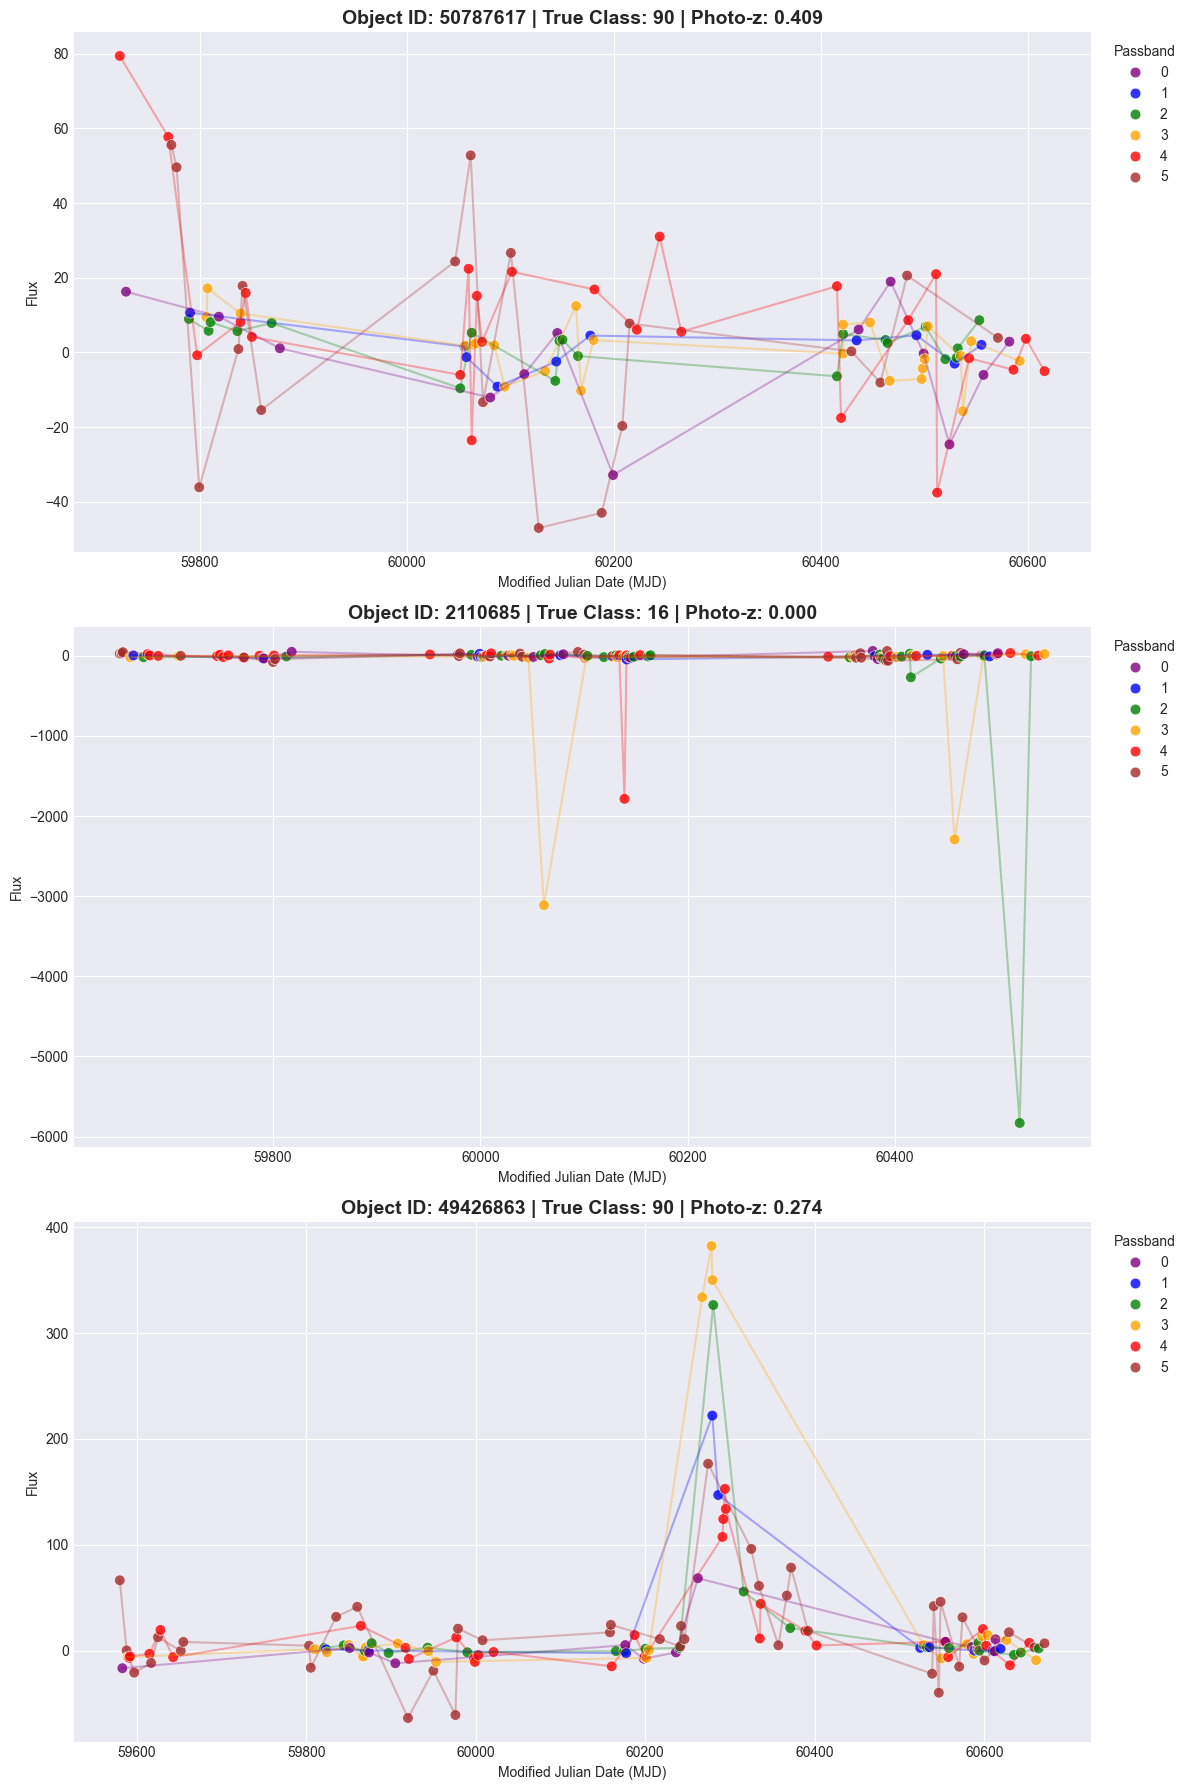

15311

In [19]:
print("--- Phase 5: Cross-Check and Holistic View ---")

# 1. Reload the training light-curves for the join
df_train_lc = pd.read_csv(lightcurve_files[0])

# 2. Alignment Cross-Check against the Phase 3 Ledger
lc_ids = set(df_train_lc['object_id'].unique())
missing_in_meta = lc_ids - master_id_ledger

if not missing_in_meta:
    print("Cross-Check PASSED: Every time-series object has a perfectly matching metadata row!")
else:
    print(f"Cross-Check FAILED: Found {len(missing_in_meta)} objects with no metadata.")

# 3. Select 3 diverse objects to visualize
# We will randomly sample 3 IDs from the loaded light-curves
sample_ids = df_train_lc['object_id'].drop_duplicates().sample(3, random_state=42).tolist()

# 4. Filter and Merge
sample_lc = df_train_lc[df_train_lc['object_id'].isin(sample_ids)]
merged_data = sample_lc.merge(master_metadata, on='object_id', how='left')

print("Data merged successfully. Generating light-curve plots...")

# 5. Plotting the Holistic View
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Standard astronomical colors for the 6 passbands
passband_colors = {0: 'purple', 1: 'blue', 2: 'green', 3: 'orange', 4: 'red', 5: 'brown'}

for idx, obj_id in enumerate(sample_ids):
    obj_data = merged_data[merged_data['object_id'] == obj_id]
    
    # Extract static metadata for the title
    target_class = obj_data['true_target'].iloc[0]
    redshift = obj_data['hostgal_photoz'].iloc[0]
    
    sns.scatterplot(data=obj_data, x='mjd', y='flux', hue='passband', 
                    palette=passband_colors, ax=axes[idx], s=60, alpha=0.8)
    sns.lineplot(data=obj_data, x='mjd', y='flux', hue='passband', 
                 palette=passband_colors, ax=axes[idx], alpha=0.3, legend=False)
    
    axes[idx].set_title(f'Object ID: {obj_id} | True Class: {target_class} | Photo-z: {redshift:.3f}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Modified Julian Date (MJD)')
    axes[idx].set_ylabel('Flux')
    axes[idx].legend(title='Passband', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Clean up memory
del df_train_lc, sample_lc, merged_data
gc.collect()

**Phase 5 Summary: The Holistic View**

Our alignment cross-check was a complete success: every single object in the dynamic time-series data has a perfectly corresponding row in our static metadata ledger. There are no orphan records.

The multi-band light-curve plots reveal the physical reality of the dataset:
* **Multi-Channel Complexity:** The objects are observed across 6 different passbands (u, g, r, i, z, y), but they are rarely observed in all 6 bands simultaneously.
* **Sparsity:** The plots visually confirm the intermittency we calculated in Phase 4. There are clear gaps in the timelines where no flux is recorded.
* **Varying Amplitudes:** Depending on the object's true class and redshift, the scale of the flux varies wildly, confirming that our preprocessing pipeline will need robust normalization techniques before feeding this into a deep learning model.

### Phase 6: Executive Summary & Next Steps

This Exploratory Data Analysis of the unblinded PLASTICC dataset has provided a clear roadmap for our modeling strategy. Here are the core takeaways:

1. **Scale and Integrity:** The universe contains approximately 3.5 million distinct objects. The static metadata and dynamic time-series data are perfectly aligned. The dataset is massive but highly structured and clean, with minimal unexpected missing values.
2. **Severe Class Imbalance:** The data is heavily skewed toward Type Ia Supernovae. Rare events, particularly Kilonovae and the anomaly "Other" class, represent a tiny fraction of the universe. This imbalance will require careful stratified sampling during our train/validation split.
3. **Extreme Temporal Irregularity:** The time-series observations are highly intermittent. Sequence lengths vary drastically, and the time gaps ($\Delta t$) between detections can span weeks. 

**Conclusion & Transition to Preprocessing**
The extreme sparsity and irregular sampling confirm that traditional sequential models (like basic RNNs or LSTMs) will struggle to maintain memory across these gaps. This mathematically validates our decision to utilize advanced architectures like **Temporal Fusion Transformers (TFT)** and **State Space Models (SSM)**. 

Because the full dataset is too large to train on, our immediate next step is data splitting. In the next notebook (`01_stratified_data_split.ipynb`), we will use our Master Metadata table to intelligently and proportionally sample exactly objects for training and for validation.